# COT Commercial Index Hypothesis Test

**Null hypothesis (H₀):** No COT Commercial Index filter configuration improves
the risk-adjusted performance of the NR3 + ORB base strategy. Any observed
improvement is indistinguishable from the best of random noise across 49
permutations.

**Method:** Hansen's Superior Predictive Ability (SPA) test with stationary
bootstrap, applied to out-of-sample daily PnL across three non-overlapping
walk-forward windows.

**Decision rule:** If SPA p-value < 0.05 → reject H₀ (keep COT).  
Otherwise → fail to reject (remove COT filters from live strategy).

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.getcwd())

from hypothesis_test import (
    build_cot_grid, grid_label, grid_to_dataframe,
    run_full_hypothesis_test, WALK_FORWARD_WINDOWS,
    INITIAL_CAPITAL,
)
from backtest_engine.data import load_cot_data

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="darkgrid")

print("Imports OK")

Imports OK


## 1. Load data

In [2]:
cot_df = load_cot_data(os.path.join(PROJECT_ROOT, "cot_data.json"))
markets = sorted(cot_df["Market"].unique().tolist())
print(f"Loaded {len(cot_df):,} rows across {len(markets)} markets")
print(f"Date range: {cot_df['Date'].min().date()} → {cot_df['Date'].max().date()}")
print(f"\nMarkets: {markets}")

Loaded 51,893 rows across 48 markets
Date range: 2022-01-03 → 2026-04-02

Markets: ['AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE', 'BITCOIN - CHICAGO MERCANTILE EXCHANGE', 'BRITISH POUND - CHICAGO MERCANTILE EXCHANGE', 'CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE', 'COCOA - ICE FUTURES U.S.', 'COFFEE C - ICE FUTURES U.S.', 'COPPER- #1 - COMMODITY EXCHANGE INC.', 'CORN - CHICAGO BOARD OF TRADE', 'COTTON NO. 2 - ICE FUTURES U.S.', 'E-MINI NATURAL GAS - NEW YORK MERCANTILE EXCHANGE', 'E-MINI S&P 500 - CHICAGO MERCANTILE EXCHANGE', 'EMINI RUSSELL 1000 GROWTH - CHICAGO MERCANTILE EXCHANGE', 'EURO FX/BRITISH POUND XRATE - CHICAGO MERCANTILE EXCHANGE', 'FEEDER CATTLE - CHICAGO MERCANTILE EXCHANGE', 'GASOLINE RBOB - NEW YORK MERCANTILE EXCHANGE', 'GOLD - COMMODITY EXCHANGE INC.', 'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE', 'LEAN HOGS - CHICAGO MERCANTILE EXCHANGE', 'LIVE CATTLE - CHICAGO MERCANTILE EXCHANGE', 'MEXICAN PESO - CHICAGO MERCANTILE EXCHANGE', 'MICRO BITCOIN - CHICAGO MERCAN

## 2. Test design

In [3]:
grid = build_cot_grid()
grid_df = grid_to_dataframe(grid)

print(f"Total configurations: {len(grid)} (1 base + {len(grid)-1} COT variants)")
print(f"\nCOT Level values : Off, 60/40, 70/30, 80/20, 90/10")
print(f"COT Direction    : Off, On")
print(f"COT ROC threshold: Off, 5, 10, 15, 20")
print(f"\nPermutation grid (first 10):")
grid_df.head(10)

Total configurations: 50 (1 base + 49 COT variants)

COT Level values : Off, 60/40, 70/30, 80/20, 90/10
COT Direction    : Off, On
COT ROC threshold: Off, 5, 10, 15, 20

Permutation grid (first 10):


,idx,label,cot_level,cot_direction,cot_roc
0,0,Base (No COT),Off,Off,Off
1,1,ROC≥5,Off,Off,5
2,2,ROC≥10,Off,Off,10
3,3,ROC≥15,Off,Off,15
4,4,ROC≥20,Off,Off,20
5,5,Dir,Off,On,Off
6,6,Dir + ROC≥5,Off,On,5
7,7,Dir + ROC≥10,Off,On,10
8,8,Dir + ROC≥15,Off,On,15
9,9,Dir + ROC≥20,Off,On,20


In [4]:
print("Walk-Forward Windows (non-overlapping OOS):\n")
for w in WALK_FORWARD_WINDOWS:
    print(f"  {w['name']}")
    print(f"    Train: {w['train_start']} → {w['train_end']}")
    print(f"    Test:  {w['test_start']} → {w['test_end']}")
    print()

Walk-Forward Windows (non-overlapping OOS):

  Window 1 (Jan–Sep 2024)
    Train: 2022-01-01 → 2023-12-31
    Test:  2024-01-01 → 2024-09-30

  Window 2 (Oct 2024–Jun 2025)
    Train: 2022-01-01 → 2024-09-30
    Test:  2024-10-01 → 2025-06-30

  Window 3 (Jul 2025–Apr 2026)
    Train: 2022-01-01 → 2025-06-30
    Test:  2025-07-01 → 2026-04-02



## 3. Run the hypothesis test

This runs 50 configurations × all markets × 3 OOS windows, then applies the SPA test.

In [5]:
results = run_full_hypothesis_test(
    cot_df, markets,
    windows=WALK_FORWARD_WINDOWS,
    grid=grid,
    n_bootstrap=1000,
    verbose=True,
)

Loading intraday cache …



Window 1 (Jan–Sep 2024)  |  OOS: 2024-01-01 → 2024-09-30
  Pre-computing base breakout signals …


  47 markets with data
  [  1/50] Base (No COT)


  [ 11/50] Lvl 60/40


  [ 21/50] Lvl 70/30


...

  [ 21/50] Lvl 70/30


  [ 31/50] Lvl 80/20


  [ 41/50] Lvl 90/10


  [ 50/50] Lvl 90/10 + Dir + ROC≥20



Building aligned PnL matrix …
  OOS trading days: 578,  COT variants: 49

Running SPA test (1000 bootstrap replications) …
  p-value = 0.8490  →  FAIL TO REJECT H₀

Computing per-variant metrics …

Done.



## 4. SPA test result

In [6]:
spa = results["spa"]

print("=" * 60)
if spa["reject_h0"]:
    print("  VERDICT:  REJECT H₀")
    print("  At least one COT filter configuration significantly")
    print("  improves performance (p < 0.05 after multiple-testing")
    print("  correction).")
else:
    print("  VERDICT:  FAIL TO REJECT H₀")
    print("  No COT filter configuration significantly improves")
    print("  performance after correcting for 49 comparisons.")
    print("  Recommendation: REMOVE COT filters from live strategy.")
print("=" * 60)
print(f"\n  SPA p-value:            {spa['pvalue']:.4f}")
print(f"  Bootstrap replications: {spa['n_bootstrap']}")
print(f"  Significance level:     0.05")

  VERDICT:  FAIL TO REJECT H₀
  No COT filter configuration significantly improves
  performance after correcting for 49 comparisons.
  Recommendation: REMOVE COT filters from live strategy.

  SPA p-value:            0.8490
  Bootstrap replications: 1000
  Significance level:     0.05


## 5. Per-variant metrics (ranked by OOS Sharpe improvement)

In [7]:
mdf = results["metrics_df"].copy()
display_cols = [
    "label", "total_trades", "win_rate", "sharpe", "sharpe_diff",
    "max_dd_pct", "max_consec_losers", "profit_factor", "net_profit", "return_pct",
]
mdf = mdf[display_cols].reset_index(drop=True)
mdf.columns = [
    "Configuration", "Trades", "Win %", "Sharpe", "Sharpe Δ",
    "Max DD %", "Max Consec L", "PF", "Net Profit", "Return %",
]
mdf

,Configuration,Trades,Win %,Sharpe,Sharpe Δ,Max DD %,Max Consec L,PF,Net Profit,Return %
0,ROC≥20,145,24.138,0.792,0.287,14.661,7,1.488,13020.050,43.400
1,Lvl 60/40 + ROC≥20,121,25.620,0.703,0.198,14.290,7,1.449,10161.160,33.871
2,Lvl 70/30 + ROC≥20,115,24.348,0.625,0.120,15.730,8,1.401,8894.380,29.648
3,Lvl 90/10 + Dir + ROC≥20,95,26.316,0.621,0.116,13.882,9,1.432,7852.730,26.176
4,Lvl 90/10 + ROC≥20,95,26.316,0.621,0.116,13.882,9,1.432,7852.730,26.176
5,Dir + ROC≥20,139,23.741,0.589,0.083,19.729,7,1.342,9007.150,30.024
6,Lvl 80/20 + Dir + ROC≥20,105,25.714,0.574,0.069,14.970,9,1.373,7374.880,24.583
7,Lvl 80/20 + ROC≥20,105,25.714,0.571,0.066,15.089,9,1.370,7327.280,24.424
8,Base (No COT),902,19.623,0.505,0.000,47.605,15,1.122,21679.150,72.264
9,ROC≥10,250,21.600,0.503,-0.002,24.961,11,1.211,10064.010,33.547


## 6. Visualisations

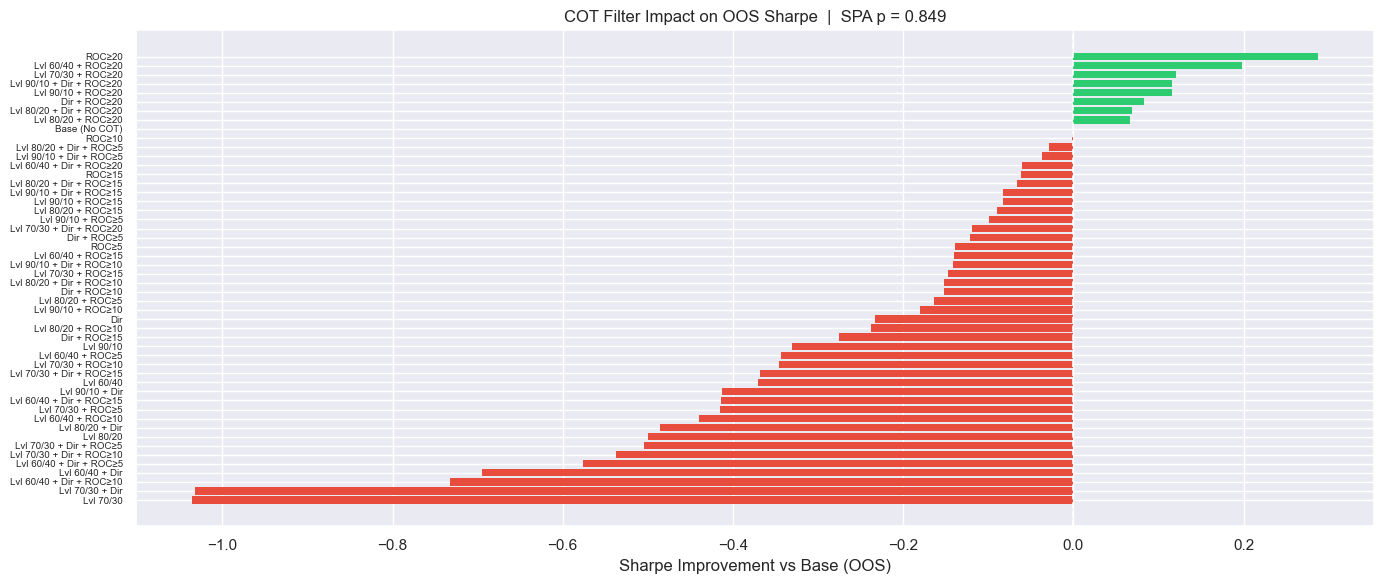

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
mdf_sorted = mdf.sort_values("Sharpe Δ", ascending=True)
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in mdf_sorted["Sharpe Δ"]]
ax.barh(range(len(mdf_sorted)), mdf_sorted["Sharpe Δ"], color=colors, edgecolor="none")
ax.set_yticks(range(len(mdf_sorted)))
ax.set_yticklabels(mdf_sorted["Configuration"], fontsize=7)
ax.axvline(0, color="white", linewidth=1.2, linestyle="--")
ax.set_xlabel("Sharpe Improvement vs Base (OOS)")
ax.set_title(f"COT Filter Impact on OOS Sharpe  |  SPA p = {spa['pvalue']:.3f}")
plt.tight_layout()
plt.show()

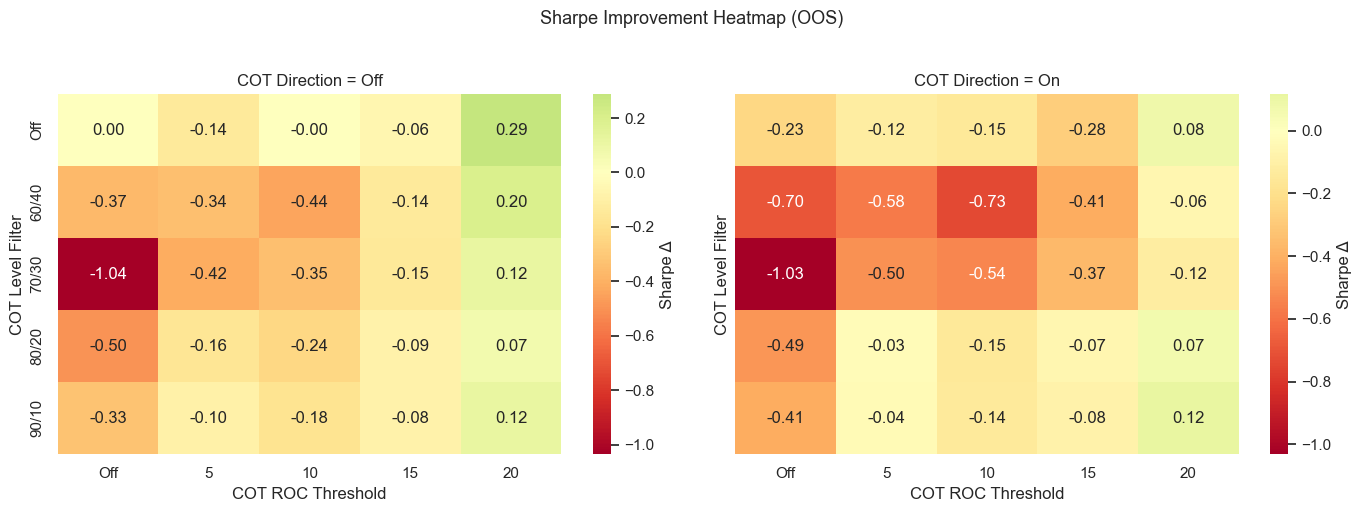

In [9]:
# Heatmap: Sharpe improvement across COT Level vs ROC, split by Direction

full_metrics = results["metrics_df"].copy()
grid = results["grid"]

heat_rows = []
for _, row in full_metrics.iterrows():
    idx = int(row["config_idx"])
    p = grid[idx]
    heat_rows.append({
        "level": f"{p['cot_long']}/{p['cot_short']}" if p.get("cot_filter") else "Off",
        "direction": "On" if p.get("cot_direction_filter") else "Off",
        "roc": str(p["cot_roc_threshold"]) if p.get("cot_roc_filter") else "Off",
        "sharpe_diff": row["sharpe_diff"],
    })

heat_df = pd.DataFrame(heat_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, dir_val in enumerate(["Off", "On"]):
    sub = heat_df[heat_df["direction"] == dir_val]
    pivot = sub.pivot_table(index="level", columns="roc", values="sharpe_diff", aggfunc="mean")
    level_order = ["Off", "60/40", "70/30", "80/20", "90/10"]
    roc_order = ["Off", "5", "10", "15", "20"]
    pivot = pivot.reindex(index=[l for l in level_order if l in pivot.index],
                          columns=[r for r in roc_order if r in pivot.columns])
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                ax=axes[i], cbar_kws={"label": "Sharpe Δ"})
    axes[i].set_title(f"COT Direction = {dir_val}")
    axes[i].set_xlabel("COT ROC Threshold")
    axes[i].set_ylabel("COT Level Filter")

fig.suptitle("Sharpe Improvement Heatmap (OOS)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Per-window consistency check

If the same (or similar) COT variant ranks highest across multiple windows,
that strengthens confidence in the result.

In [10]:
consistency = pd.DataFrame(results["per_window_best"])
print("Best-performing configuration per OOS window:\n")
consistency

Best-performing configuration per OOS window:



,window,best_config_idx,best_label,best_sharpe
0,Window 1 (Jan–Sep 2024),24,Lvl 70/30 + ROC≥20,0.823
1,Window 2 (Oct 2024–Jun 2025),5,Dir,1.857
2,Window 3 (Jul 2025–Apr 2026),9,Dir + ROC≥20,0.706


## 8. Cumulative OOS equity: Base vs best COT variant

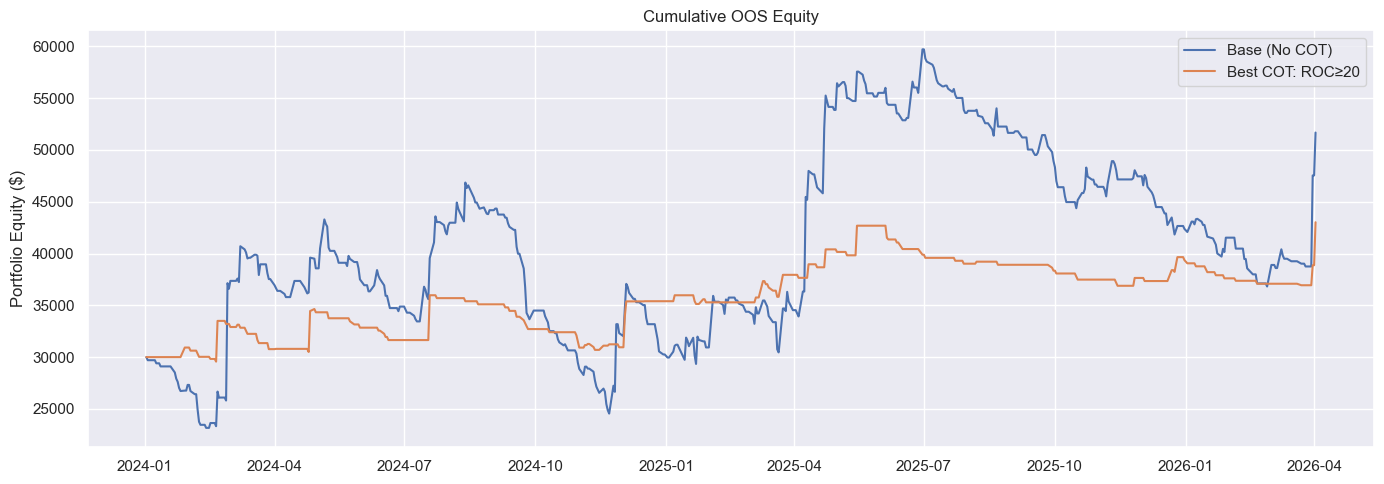

In [11]:
best_variant_row = results["metrics_df"].iloc[0]  # already sorted by sharpe_diff desc
best_idx = int(best_variant_row["config_idx"])
best_label = best_variant_row["label"]

dates = results["dates"]
base_cum = INITIAL_CAPITAL + np.cumsum(results["base_pnl"])

# Find the variant column index
vi_list = results["variant_indices"]
if best_idx in vi_list:
    col = vi_list.index(best_idx)
    best_cum = INITIAL_CAPITAL + np.cumsum(results["variant_pnl"][:, col])
else:
    best_cum = base_cum  # best IS the base

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, base_cum, label="Base (No COT)", linewidth=1.5)
if best_idx != 0:
    ax.plot(dates, best_cum, label=f"Best COT: {best_label}", linewidth=1.5)
ax.set_ylabel("Portfolio Equity ($)")
ax.set_title("Cumulative OOS Equity")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Conclusion

In [12]:
print("=" * 60)
print("CONCLUSION")
print("=" * 60)
print()
print(f"Base strategy Sharpe (OOS):  {results['metrics_df'][results['metrics_df']['config_idx']==0]['sharpe'].values[0]:.3f}")
print(f"Best COT variant Sharpe:     {best_variant_row['sharpe']:.3f}  ({best_label})")
print(f"Sharpe improvement:          {best_variant_row['sharpe_diff']:+.3f}")
print()
print(f"SPA p-value:                 {spa['pvalue']:.4f}")
print()

if spa["reject_h0"]:
    print("REJECT H₀ — the COT Commercial Index provides a statistically")
    print("significant improvement to the NR3 + ORB strategy after")
    print("correcting for 49 simultaneous comparisons.")
    print(f"\nRecommended configuration: {best_label}")
else:
    print("FAIL TO REJECT H₀ — there is no statistically significant")
    print("evidence that any COT filter configuration improves the")
    print("NR3 + ORB strategy after correcting for multiple comparisons.")
    print("\nRecommendation: REMOVE all COT filters from live trading.")
    print("The base strategy without COT is the appropriate default.")

CONCLUSION

Base strategy Sharpe (OOS):  0.505
Best COT variant Sharpe:     0.792  (ROC≥20)
Sharpe improvement:          +0.287

SPA p-value:                 0.8490

FAIL TO REJECT H₀ — there is no statistically significant
evidence that any COT filter configuration improves the
NR3 + ORB strategy after correcting for multiple comparisons.

Recommendation: REMOVE all COT filters from live trading.
The base strategy without COT is the appropriate default.
